In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

In [2]:
# Root directory containing Ray Tune trial folders (PPO_*).
root = Path("results")
if not root.exists():
    raise FileNotFoundError(f"No results directory at {root.resolve()}")

# Discover trial directories.
trial_dirs = sorted([p for p in root.rglob('PPO_*') if p.is_dir()])
if not trial_dirs:
    raise FileNotFoundError(f'No trial directories found under {root.resolve()}')
trial_dirs[:5]

[PosixPath('results/mappo_atoc_event/PPO_aced_payload_pettingzoo_v0_2bf5c_00000_0_2025-12-17_19-47-47'),
 PosixPath('results/mappo_atoc_event/PPO_aced_payload_pettingzoo_v0_3ae3e_00000_0_2025-12-18_17-45-19'),
 PosixPath('results/mappo_atoc_event/PPO_aced_payload_pettingzoo_v0_89a6e_00000_0_2025-12-16_21-17-29'),
 PosixPath('results/mappo_atoc_event/PPO_aced_payload_pettingzoo_v0_95ac6_00000_0_2025-12-14_13-34-57'),
 PosixPath('results/mappo_atoc_event/PPO_aced_payload_pettingzoo_v0_f844c_00000_0_2025-12-17_18-06-07')]

In [3]:
# Summarize trials using the existing helper.
from src.summarize_results import summarize_trial

summaries = []
for td in trial_dirs:
    summary = summarize_trial(td, root)
    summary['trial_path'] = str(td)
    summary['progress_path'] = str(td / 'progress.csv')
    summaries.append(summary)

df = pd.DataFrame(summaries)
custom_df = pd.json_normalize(df['custom_metrics'].fillna({}), sep='_')
df_flat = pd.concat([df.drop(columns=['custom_metrics']), custom_df], axis=1)
df_flat = df_flat[df_flat["config"] != "quick_test"]
# df_flat = df_flat[df_flat["config"] == "quick_test"]

# keep only one trial per config
df_flat = df_flat.sort_values(by='last_timestamp')
df_flat = df_flat.drop_duplicates(subset='config', keep='last')

config_labels = {
    "mappo_sync_baseline": "MAPPO Baseline",
    "mappo_atoc_sync": "MAPPO + ATOC",
    "mappo_event_baseline": "MAPPO + Event-Driven",
    "mappo_atoc_event": "MAPPO + ATOC + Event-Driven",
    "quick_test": "Quick Test",
}

# rename config to config_label
df_flat['config'] = df_flat['config'].map(config_labels)

df_flat.head(10)

,trial,config,iterations,best_return_mean,best_iteration,last_return_mean,last_episode_len_mean,total_env_steps,total_agent_steps,last_timestamp,checkpoint,trial_path,progress_path,contact_fraction_mean,contact_fraction_min,contact_fraction_max,avg_contact_fraction_mean,avg_contact_fraction_min,avg_contact_fraction_max,success_rate_mean,success_rate_min,success_rate_max,dist_to_goal_mean,dist_to_goal_min,dist_to_goal_max
8,PPO_aced_payload_pettingzoo_v0_d47aa_00000_0_2...,MAPPO + ATOC,200,604.991077,167,447.045530,105.36,800000,4000000,2025-12-17_22-03-14,results/mappo_atoc_sync/PPO_aced_payload_petti...,results/mappo_atoc_sync/PPO_aced_payload_petti...,results/mappo_atoc_sync/PPO_aced_payload_petti...,0.408,0.2,1.0,0.856820,0.606200,1.000000,0.03,0.0,1.0,13.298124,4.865455,22.856024
13,PPO_aced_payload_pettingzoo_v0_bcd2e_00000_0_2...,MAPPO + Event-Driven,200,1205.181789,47,364.176103,97.96,800000,4000000,2025-12-17_22-05-29,results/mappo_event_baseline/PPO_aced_payload_...,results/mappo_event_baseline/PPO_aced_payload_...,results/mappo_event_baseline/PPO_aced_payload_...,0.378,0.2,0.6,0.868413,0.668657,0.995848,0.01,0.0,1.0,13.628095,4.902000,23.635665
19,PPO_aced_payload_pettingzoo_v0_9c6d2_00000_0_2...,MAPPO Baseline,200,506.759990,29,380.617996,88.89,800000,4000000,2025-12-17_22-05-52,results/mappo_sync_baseline/PPO_aced_payload_p...,results/mappo_sync_baseline/PPO_aced_payload_p...,results/mappo_sync_baseline/PPO_aced_payload_p...,0.396,0.2,0.8,0.852172,0.620500,0.976147,0.01,0.0,1.0,13.916895,4.931552,21.639650
1,PPO_aced_payload_pettingzoo_v0_3ae3e_00000_0_2...,MAPPO + ATOC + Event-Driven,200,2374.725305,73,263.066710,61.16,800000,4000000,2025-12-18_19-27-01,results/mappo_atoc_event/PPO_aced_payload_pett...,results/mappo_atoc_event/PPO_aced_payload_pett...,results/mappo_atoc_event/PPO_aced_payload_pett...,0.392,0.2,1.0,0.856237,0.671053,1.000000,0.02,0.0,1.0,14.054761,4.820824,24.198710


## Trial leaderboard
Top trials sorted by best mean return.

In [4]:
overview_cols = [
    'config', 'trial', 'iterations', 'best_return_mean', 'best_iteration',
    'last_return_mean', 'last_episode_len_mean', 'total_env_steps', 'checkpoint'
]
leaderboard = df_flat.sort_values('best_return_mean', ascending=False)
leaderboard[overview_cols].reset_index(drop=True).head(10)

,config,trial,iterations,best_return_mean,best_iteration,last_return_mean,last_episode_len_mean,total_env_steps,checkpoint
0,MAPPO + ATOC + Event-Driven,PPO_aced_payload_pettingzoo_v0_3ae3e_00000_0_2...,200,2374.725305,73,263.066710,61.16,800000,results/mappo_atoc_event/PPO_aced_payload_pett...
1,MAPPO + Event-Driven,PPO_aced_payload_pettingzoo_v0_bcd2e_00000_0_2...,200,1205.181789,47,364.176103,97.96,800000,results/mappo_event_baseline/PPO_aced_payload_...
2,MAPPO + ATOC,PPO_aced_payload_pettingzoo_v0_d47aa_00000_0_2...,200,604.991077,167,447.045530,105.36,800000,results/mappo_atoc_sync/PPO_aced_payload_petti...
3,MAPPO Baseline,PPO_aced_payload_pettingzoo_v0_9c6d2_00000_0_2...,200,506.759990,29,380.617996,88.89,800000,results/mappo_sync_baseline/PPO_aced_payload_p...


## Best return by config
Bar plot of best mean episode return per config (one bar per trial).

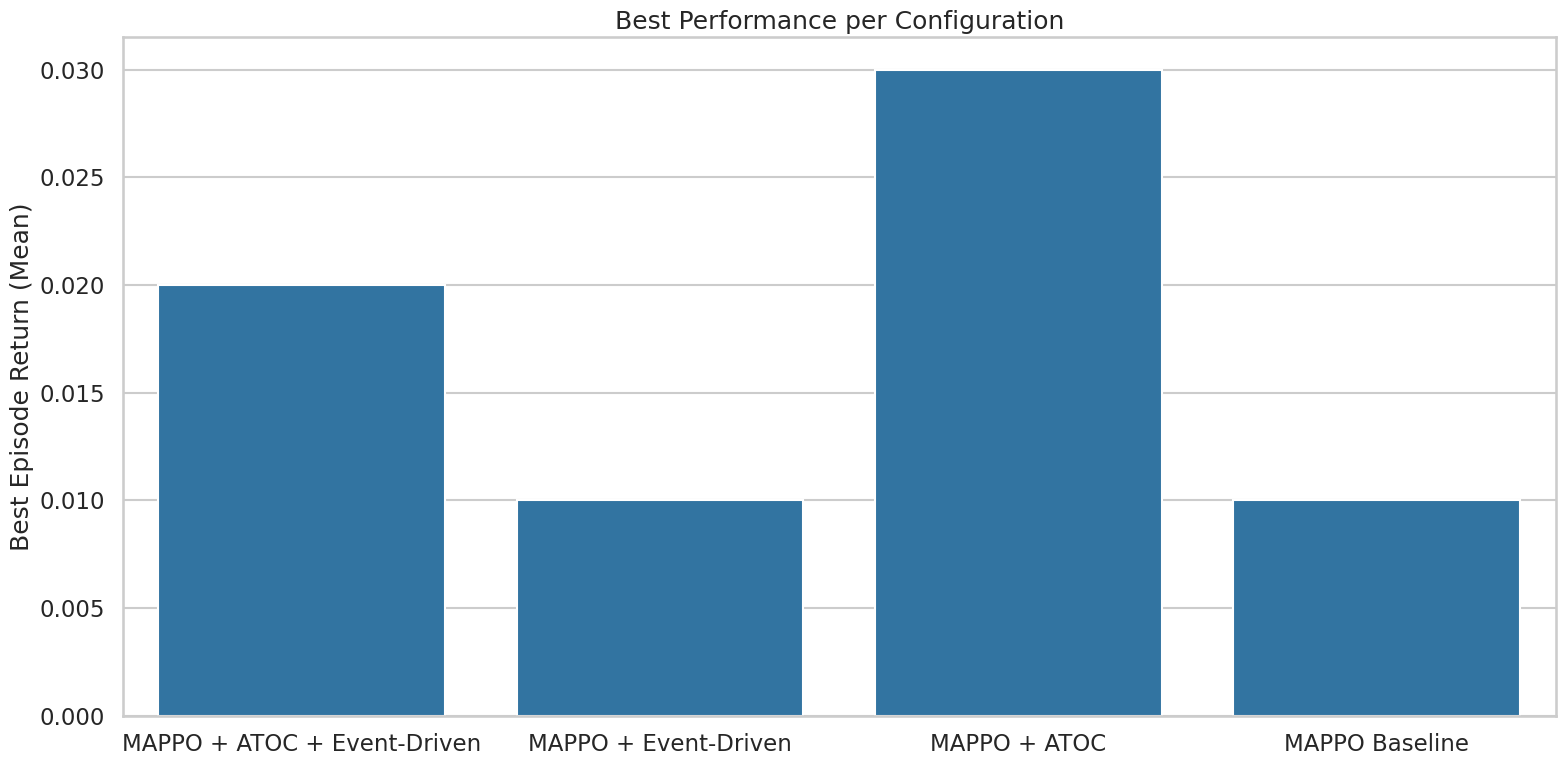

In [5]:
# metric = "best_return_mean"
metric = "success_rate_mean"
plot_data = leaderboard.dropna(subset=[metric]).copy()

plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=plot_data,
    x="config",
    y=metric,
)

ax.set_ylabel("Best Episode Return (Mean)")
ax.set_xlabel("")
ax.set_title("Best Performance per Configuration")

# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        xytext=(0, 3),
        textcoords="offset points",
        color="white"
    )

plt.tight_layout()
plt.show()

## Training curves
Select the top trial (by best_return_mean) and plot its training trajectory.

In [6]:
dfs = []
for config_name, path in zip(plot_data["config"], plot_data["progress_path"]):
    df = pd.read_csv(path)
    df["config"] = config_name
    dfs.append(df)
all_progress = pd.concat(dfs, ignore_index=True)
# rename all cols to remove path prefix
all_progress.columns = [col.split("/")[-1] for col in all_progress.columns]

all_progress.head()

,num_healthy_workers,actor_manager_num_outstanding_async_reqs,num_remote_worker_restarts,num_agent_steps_sampled,num_agent_steps_trained,num_env_steps_sampled,num_env_steps_trained,num_env_steps_sampled_this_iter,num_env_steps_trained_this_iter,num_env_steps_sampled_throughput_per_sec,num_env_steps_trained_throughput_per_sec,timesteps_total,num_env_steps_sampled_lifetime,num_agent_steps_sampled_lifetime,num_steps_trained_this_iter,agent_timesteps_total,done,training_iteration,trial_id,date,timestamp,time_this_iter_s,time_total_s,pid,hostname,node_ip,time_since_restore,iterations_since_restore,num_env_steps_sampled,num_env_steps_trained,num_agent_steps_sampled,num_agent_steps_trained,episode_reward_max,episode_reward_min,episode_reward_mean,episode_len_mean,episodes_timesteps_total,num_faulty_episodes,num_episodes,episode_return_max,episode_return_min,episode_return_mean,episodes_this_iter,training_iteration_time_ms,restore_workers_time_ms,training_step_time_ms,sample_time_ms,learn_time_ms,learn_throughput,synch_weights_time_ms,num_env_steps_sampled,num_env_steps_trained,num_agent_steps_sampled,num_agent_steps_trained,cpu_util_percent,ram_util_percent,shared_policy,shared_policy,shared_policy,contact_fraction_mean,contact_fraction_min,contact_fraction_max,avg_contact_fraction_mean,avg_contact_fraction_min,avg_contact_fraction_max,success_rate_mean,success_rate_min,success_rate_max,dist_to_goal_mean,dist_to_goal_min,dist_to_goal_max,episode_reward,episode_lengths,policy_shared_policy_reward,mean_raw_obs_processing_ms,mean_inference_ms,mean_action_processing_ms,mean_env_wait_ms,mean_env_render_ms,ObsPreprocessorConnector_ms,StateBufferConnector_ms,ViewRequirementAgentConnector_ms,num_agent_steps_trained,num_grad_updates_lifetime,diff_num_grad_updates_vs_sampler_policy,allreduce_latency,grad_gnorm,cur_kl_coeff,cur_lr,total_loss,policy_loss,vf_loss,vf_explained_var,kl,entropy,entropy_coeff,config
0,4,0,0,20000,20000,4000,4000,4000,4000,133.439799,133.439799,4000,4000,20000,4000,20000,False,1,3ae3e_00000,2025-12-18_17-46-16,1766097976,29.994720,29.994720,637387,dh-node8,10.199.0.8,29.994720,1,4000,4000,20000,20000,385.672299,-89.274355,39.253112,15.335907,3972,0,259,385.672299,-89.274355,39.253112,259,29976.074,0.016,29976.001,11484.309,18465.218,216.623,16.289,4000,4000,20000,20000,6.825581,5.800000,-22.971620,82.579120,7.850622,0.373745,0.0,0.8,0.855333,0.646154,0.966667,0.027027,0.0,1.0,13.980270,4.315711,28.809527,"[51.74230149423238, 28.732404604554176, 55.703...","[14, 21, 12, 29, 17, 19, 22, 17, 16, 12, 14, 1...","[6.1417650285875425, 12.656996726989746, 10.44...",4.160673,3.671943,1.052796,1.782038,0.0,0.024722,0.026312,1.196198,127.388535,1178.0,1177.0,0.0,2.409230,0.2,0.0003,3.492000,0.000043,7.018964,0.132494,0.001866,1.789874,0.01,MAPPO + ATOC + Event-Driven
1,4,0,0,40000,40000,8000,8000,4000,4000,133.799506,133.799506,8000,8000,40000,4000,40000,False,2,3ae3e_00000,2025-12-18_17-46-46,1766098006,29.916060,59.910780,637387,dh-node8,10.199.0.8,59.910780,2,8000,8000,40000,40000,419.913881,-94.906336,38.987751,15.284615,3974,0,260,419.913881,-94.906336,38.987751,260,29935.784,0.021,29935.710,11398.589,18513.609,216.057,14.149,8000,8000,40000,40000,6.960465,5.800000,-25.478446,88.488621,7.797550,0.367692,0.0,1.0,0.852073,0.676923,1.000000,0.026923,0.0,1.0,14.101543,4.684055,24.320203,"[102.3437298797071, 54.31171006709337, 74.2534...","[19, 12, 16, 12, 9, 15, 17, 11, 15, 16, 17, 11...","[18.117438174784184, 22.33365088701248, 17.773...",4.200589,3.659357,1.048554,1.778604,0.0,0.026755,0.029206,1.220471,127.388535,3533.0,1177.0,0.0,3.357433,0.1,0.0003,3.437410,-0.002646,6.914846,0.196445,0.005135,1.788008,0.01,MAPPO + ATOC + Event-Driven
2,4,0,0,60000,60000,12000,12000,4000,4000,136.640462,136.640462,12000,12000,60000,4000,60000,False,3,3ae3e_00000,2025-12-18_17-47-15,1766098035,29.296418,89.207198,637387,dh-node8,10.199.0.8,89.207198,3,12000,12000,60000,60000,350.831045,-97.575923,39.690499,16.225806,4024,0,248,350.831045,-97

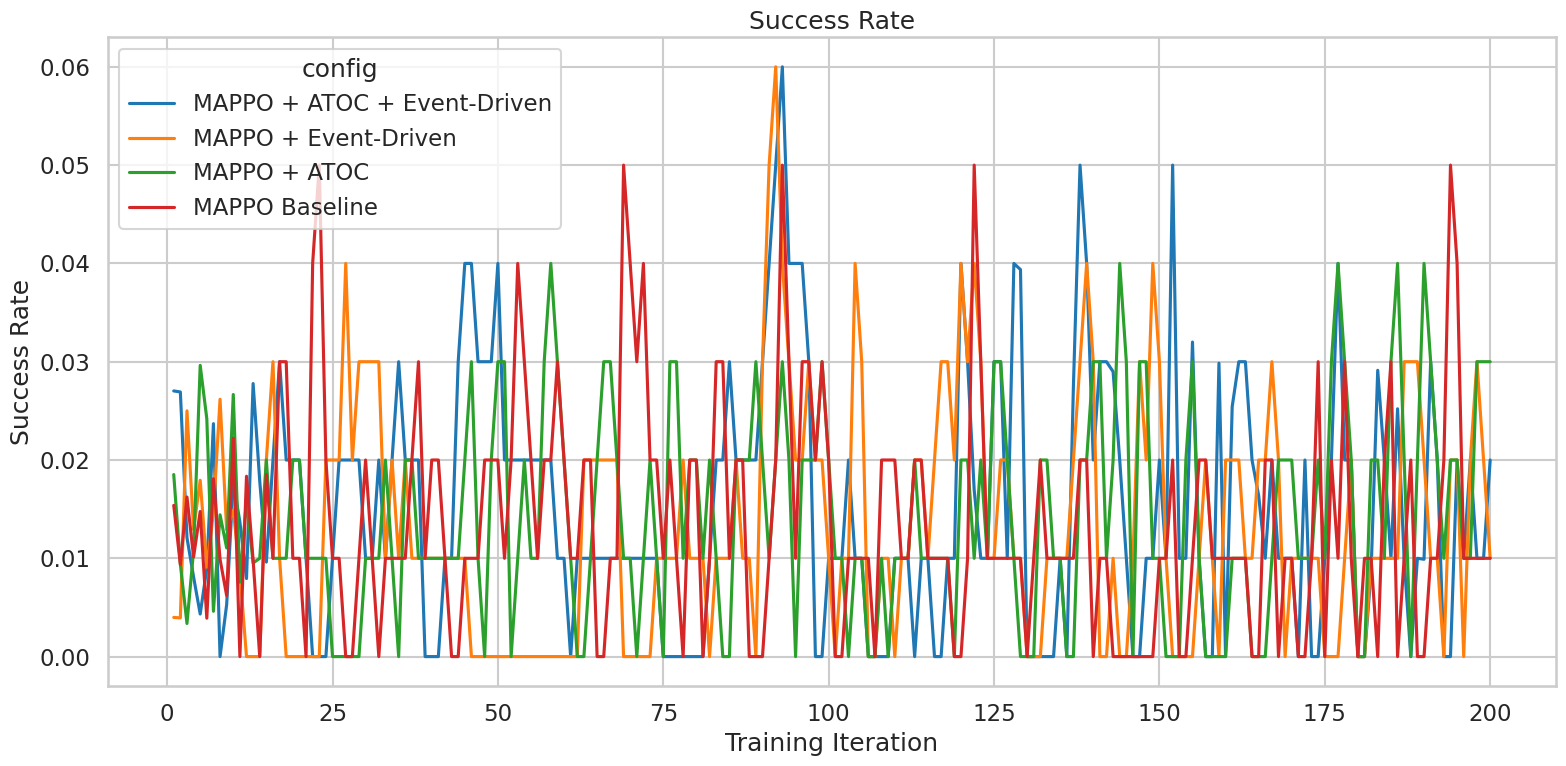

In [7]:

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=all_progress,
    x="training_iteration",
    y="success_rate_mean",
    hue="config",
)
plt.title("Success Rate")
plt.xlabel("Training Iteration")
plt.ylabel("Success Rate")
plt.tight_layout()
plt.show()

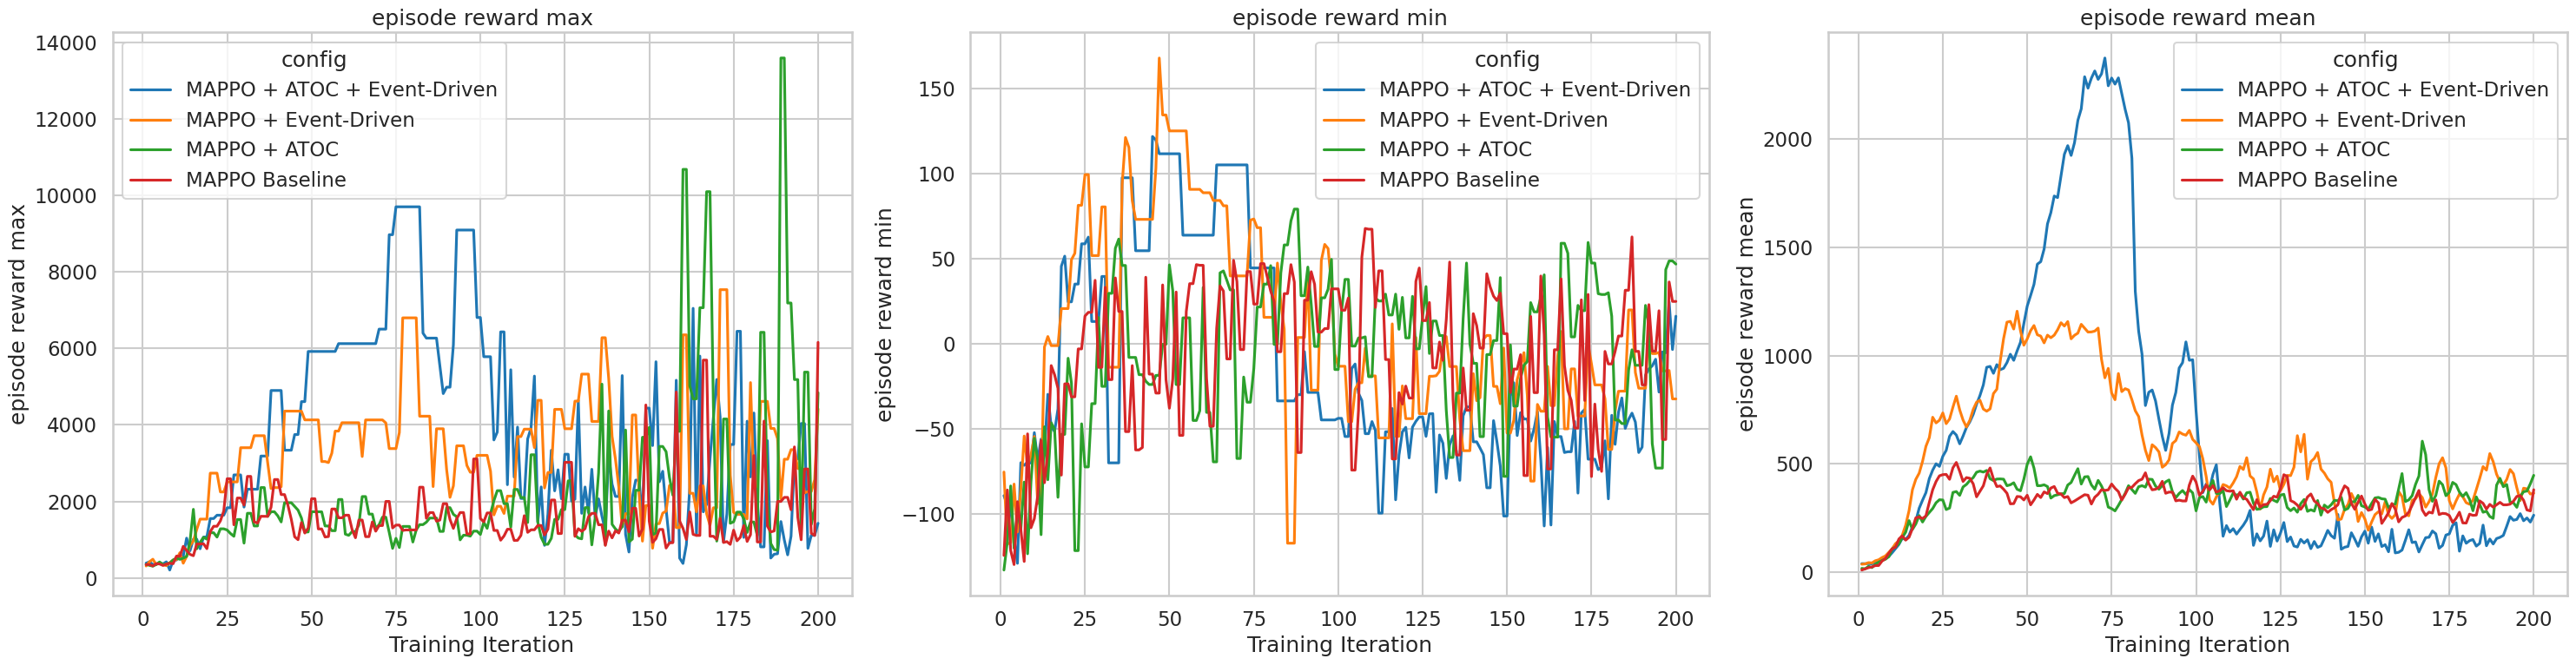

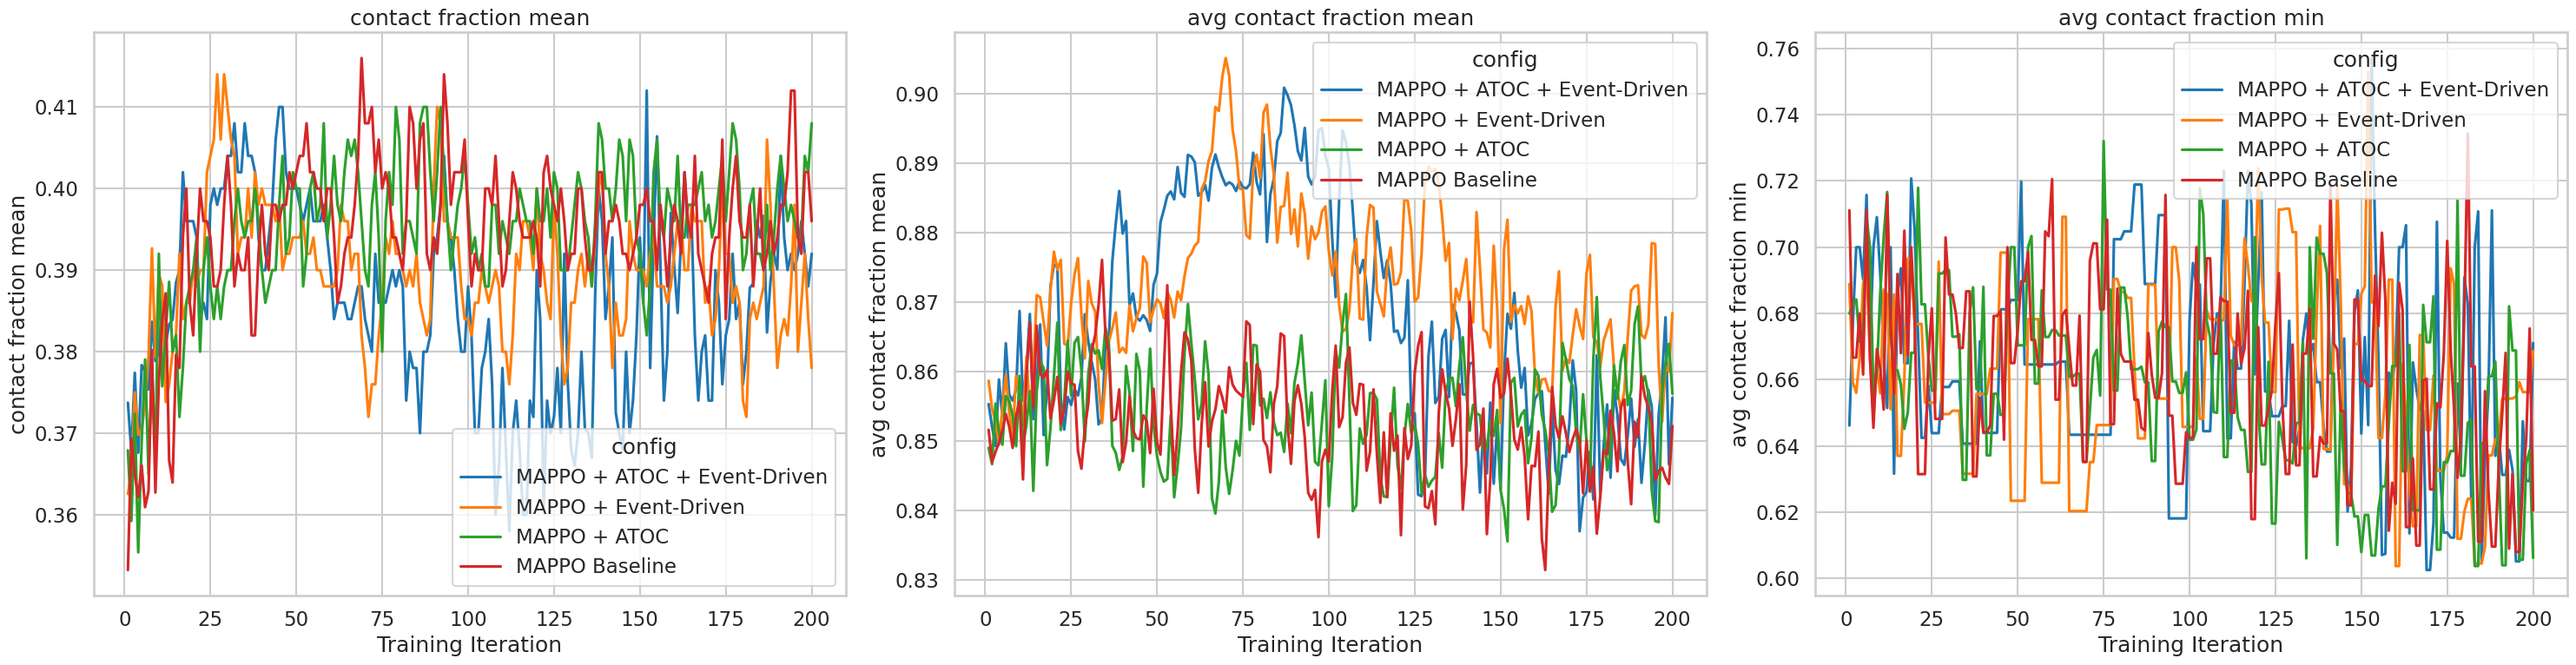

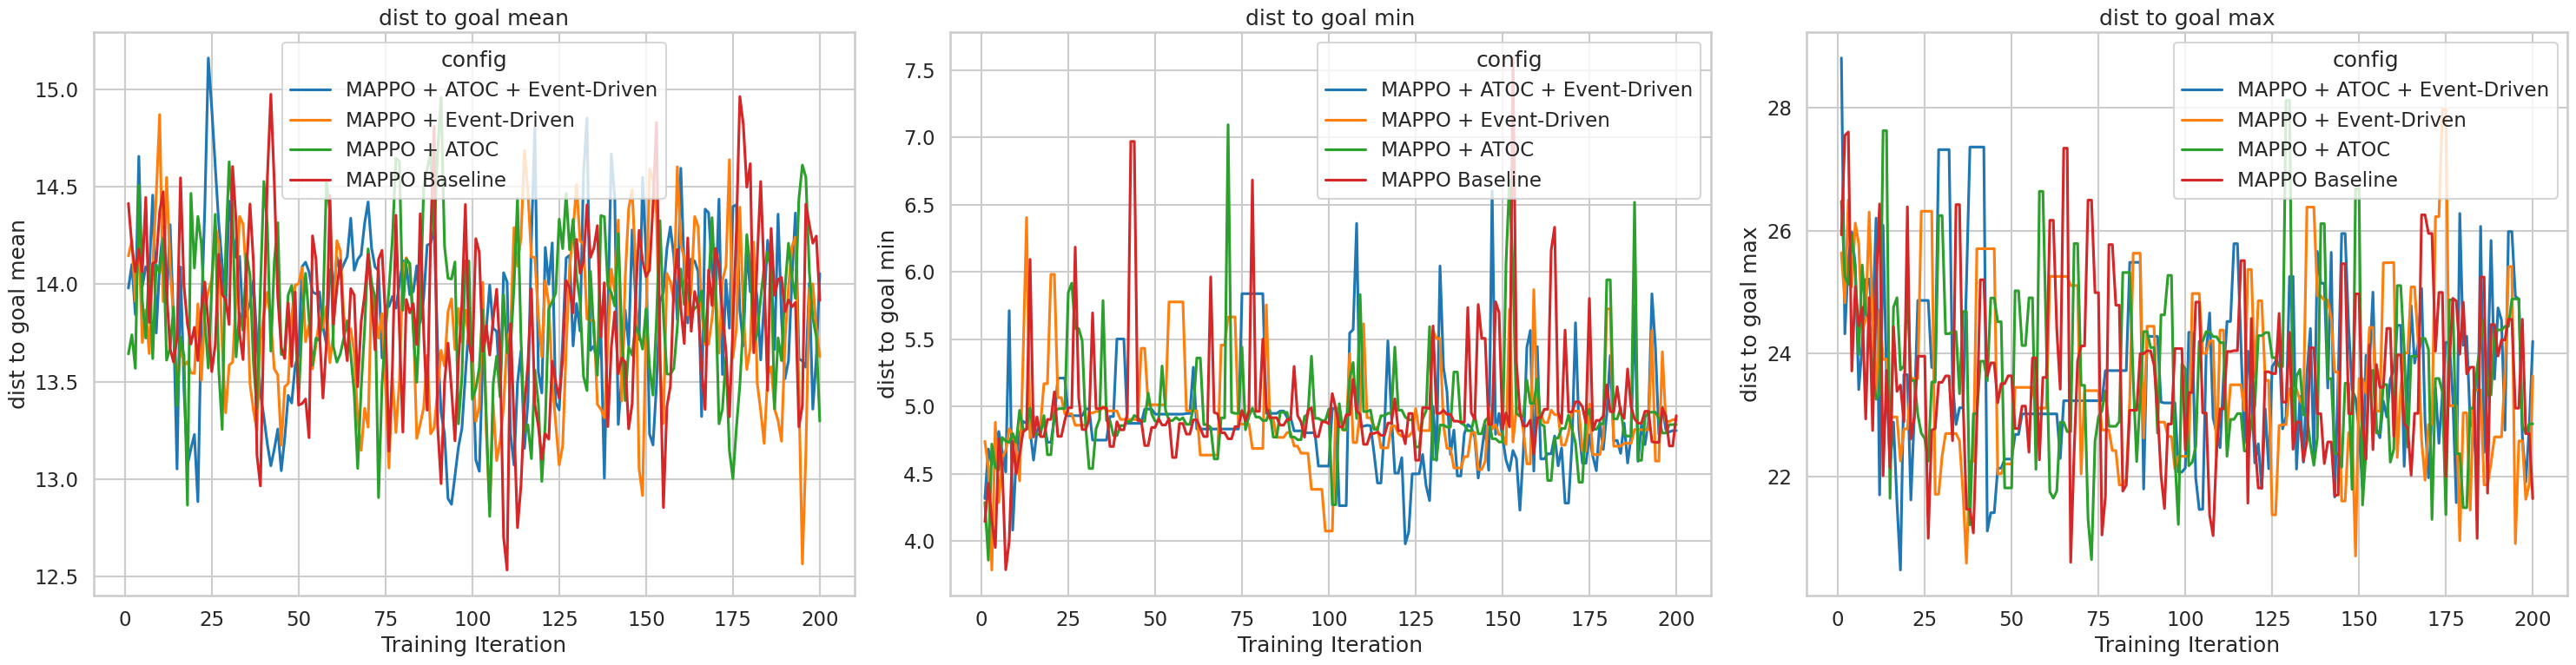

In [8]:
metric_filter = [
    # "episode_len",
    "episode_reward",
    "contact_fraction",
    "dist_to_goal",
]

drop_metrics = [
    "contact_fraction_min",
    "contact_fraction_max",
    "success_rate_min",
    "avg_contact_fraction_max",
    "episode_reward",
    "episode_lengths",
]

for metric in metric_filter:
    metrics = [col for col in all_progress.columns if metric in col]
    metrics = [m for m in metrics if m not in drop_metrics]
    num_cols = len(metrics) // 2 if len(metrics) > 3 else len(metrics)
    num_rows = (len(metrics) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10 * num_cols, 8*num_rows))
    axes = axes.flatten()
    for m, ax in zip(metrics, axes):
        ax.set_title(m.replace("_", " "))
        ax.set_xlabel("Training Iteration")
        ax.set_ylabel(m.replace("_", " "))
        sns.lineplot(
            data=all_progress,
            x="training_iteration",
            y=m,
            hue="config",
            ax=ax,
        )
    plt.tight_layout()
    plt.show()

## Custom metrics snapshot
Display any custom metrics captured in the Ray Tune payloads.

In [9]:
base_cols = {
    "trial",
    "config",
    "iterations",
    "best_return_mean",
    "best_iteration",
    "last_return_mean",
    "last_episode_len_mean",
    "total_env_steps",
    "total_agent_steps",
    "last_timestamp",
    "checkpoint",
    "trial_path",
    "progress_path",
}
custom_cols = [c for c in df_flat.columns if c not in base_cols]
if not custom_cols:
    result = "No custom metrics present."
else:
    result = df_flat[["trial", "config"] + custom_cols].head(20)

result

,trial,config,contact_fraction_mean,contact_fraction_min,contact_fraction_max,avg_contact_fraction_mean,avg_contact_fraction_min,avg_contact_fraction_max,success_rate_mean,success_rate_min,success_rate_max,dist_to_goal_mean,dist_to_goal_min,dist_to_goal_max
8,PPO_aced_payload_pettingzoo_v0_d47aa_00000_0_2...,MAPPO + ATOC,0.408,0.2,1.0,0.856820,0.606200,1.000000,0.03,0.0,1.0,13.298124,4.865455,22.856024
13,PPO_aced_payload_pettingzoo_v0_bcd2e_00000_0_2...,MAPPO + Event-Driven,0.378,0.2,0.6,0.868413,0.668657,0.995848,0.01,0.0,1.0,13.628095,4.902000,23.635665
19,PPO_aced_payload_pettingzoo_v0_9c6d2_00000_0_2...,MAPPO Baseline,0.396,0.2,0.8,0.852172,0.620500,0.976147,0.01,0.0,1.0,13.916895,4.931552,21.639650
1,PPO_aced_payload_pettingzoo_v0_3ae3e_00000_0_2...,MAPPO + ATOC + Event-Driven,0.392,0.2,1.0,0.856237,0.671053,1.000000,0.02,0.0,1.0,14.054761,4.820824,24.198710


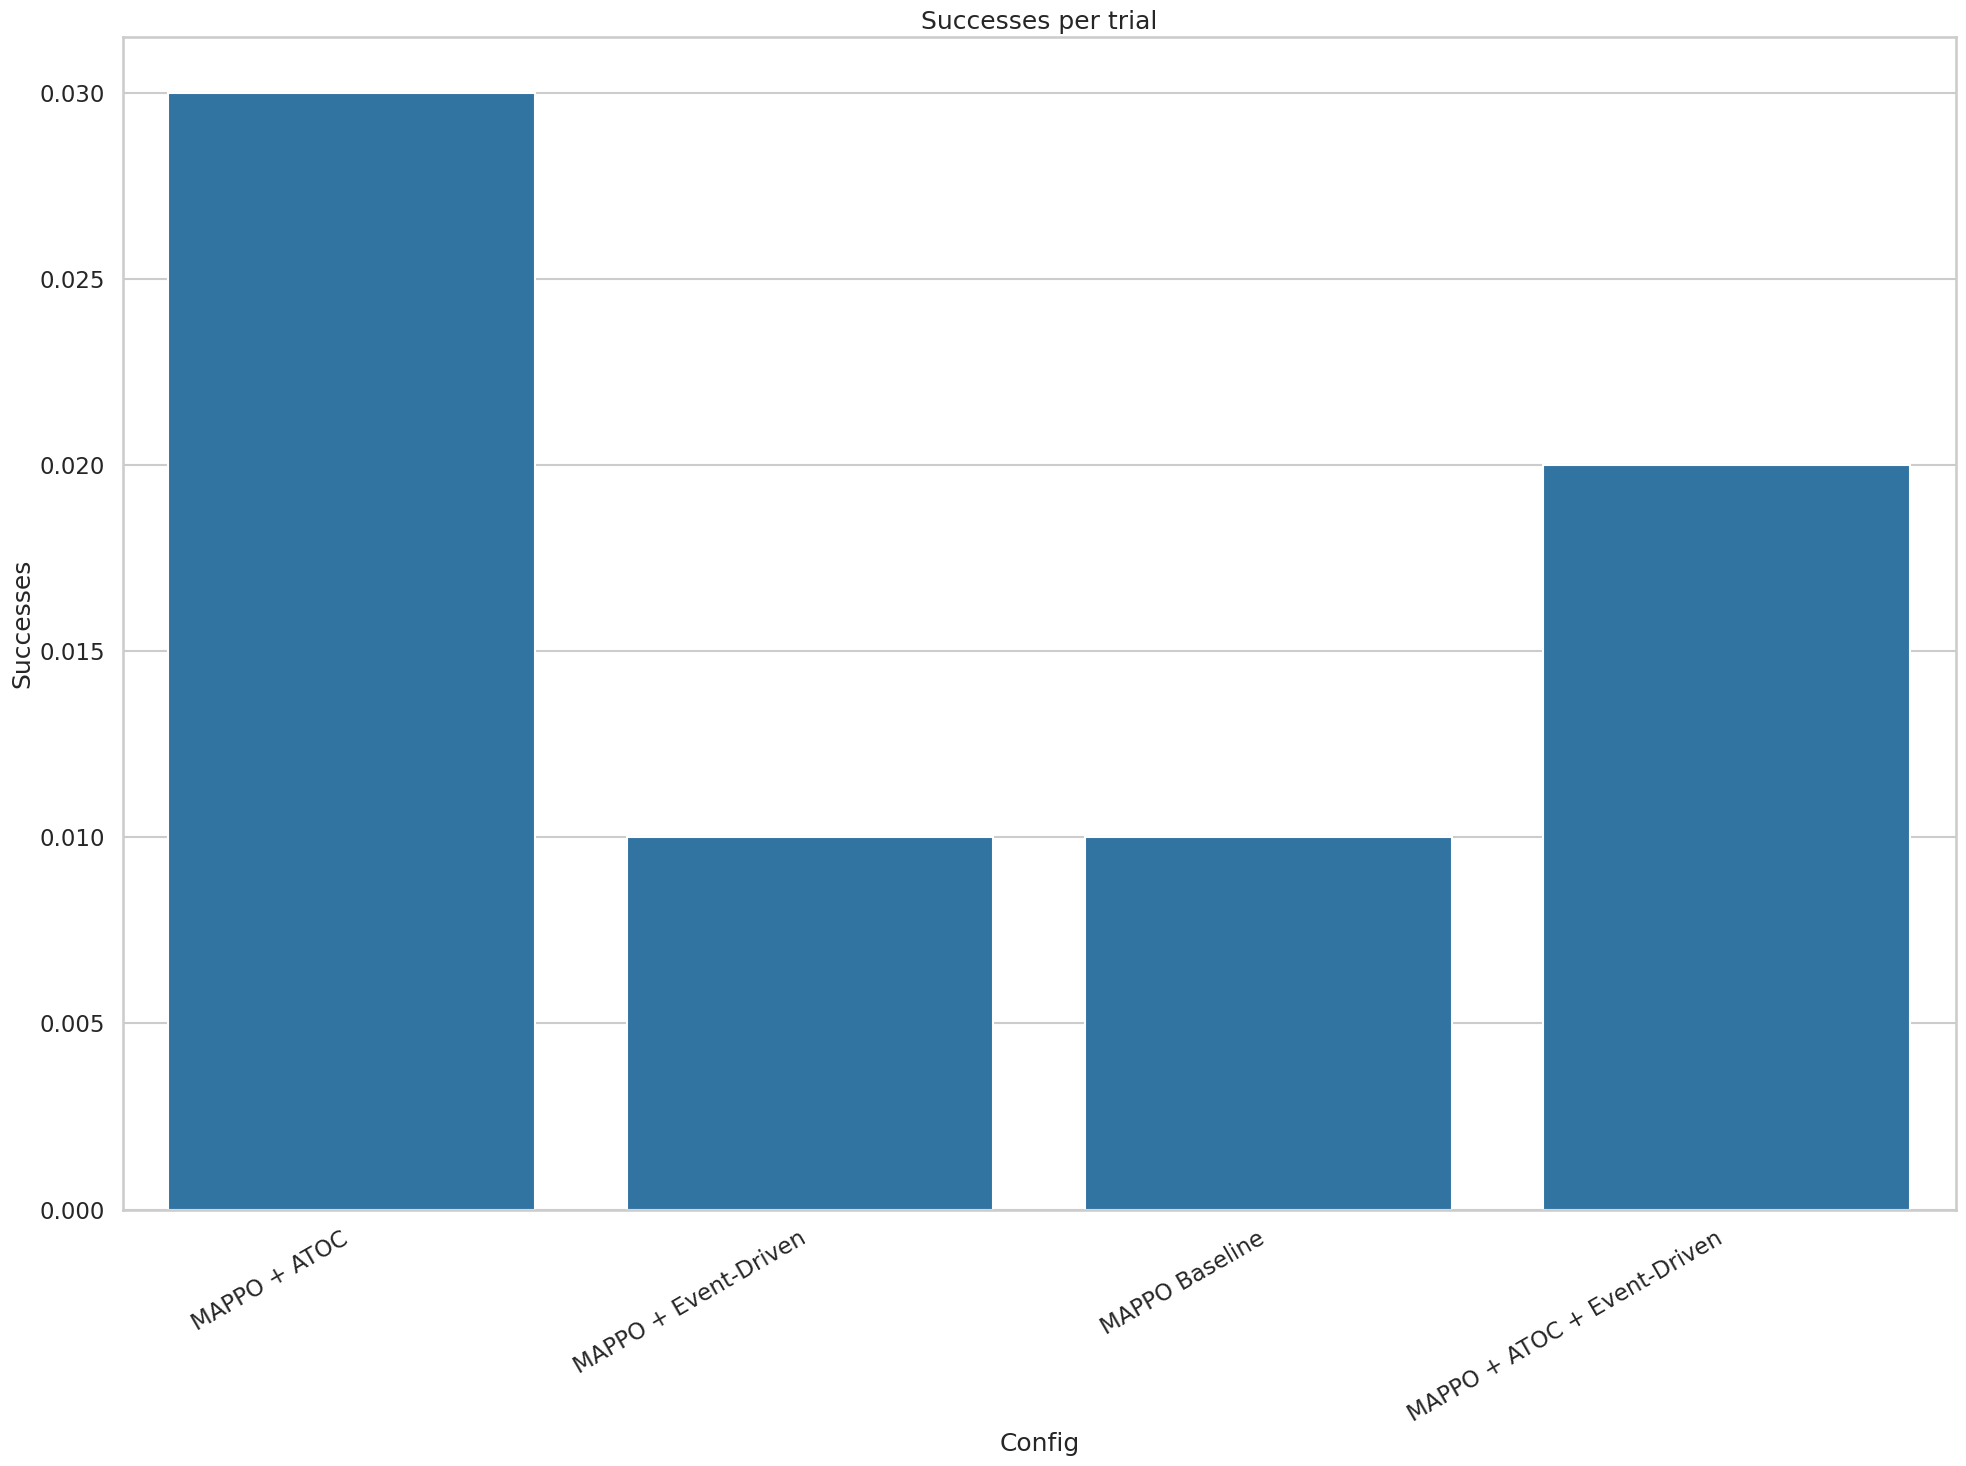

In [10]:
# plot successes
plt.figure(figsize=(20, 15))
sns.barplot(data=df_flat, x="config", y="success_rate_mean")
plt.ylabel('Successes')
plt.xlabel('Config')
plt.title('Successes per trial')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Generated

In [11]:
# Helpers and figure output directory
from pathlib import Path
import numpy as np
import os

FIG_DIR = Path("presentation/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Sort configs by mean best_return_mean for consistent storytelling
if (
    "df_flat" in globals()
    and not df_flat.empty
    and "best_return_mean" in df_flat.columns
):
    config_order = (
        df_flat.groupby("config")["best_return_mean"]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )
else:
    config_order = (
        sorted(df_flat["config"].dropna().unique().tolist())
        if "df_flat" in globals()
        else []
    )

# Consistent palette per config
palette = sns.color_palette("Set2", max(len(config_order), 3))
config_palette = {c: palette[i % len(palette)] for i, c in enumerate(config_order)}


RETURN_METRIC_CANDIDATES = [
    "env_runners/episode_return_mean",
    "env_runners/episode_reward_mean",
    "episode_return_mean",
    "episode_reward_mean",
]


def choose_return_metric(progress_df):
    if progress_df is None:
        return None
    for m in RETURN_METRIC_CANDIDATES:
        if m in progress_df.columns:
            return m
    return None


def compute_pareto(
    df, x="dist_to_goal", y="success_rate_mean", minimize_x=True, maximize_y=True
):
    if df is None or df.empty or x not in df.columns or y not in df.columns:
        return pd.DataFrame()
    # Filter rows with valid values
    d = df.dropna(subset=[x, y]).copy()
    if d.empty:
        return d
    # Non-dominated: No other point better in both dimensions.
    pareto_idx = []
    pts = d[[x, y]].values
    for i in range(len(pts)):
        xi, yi = pts[i]
        dominated = False
        for j in range(len(pts)):
            if i == j:
                continue
            xj, yj = pts[j]
            better_x = (xj <= xi) if minimize_x else (xj >= xi)
            better_y = (yj >= yi) if maximize_y else (yj <= yi)
            strict_better = ((xj < xi) if minimize_x else (xj > xi)) or (
                (yj > yi) if maximize_y else (yj < yi)
            )
            if better_x and better_y and strict_better:
                dominated = True
                break
        if not dominated:
            pareto_idx.append(i)
    return d.iloc[pareto_idx]

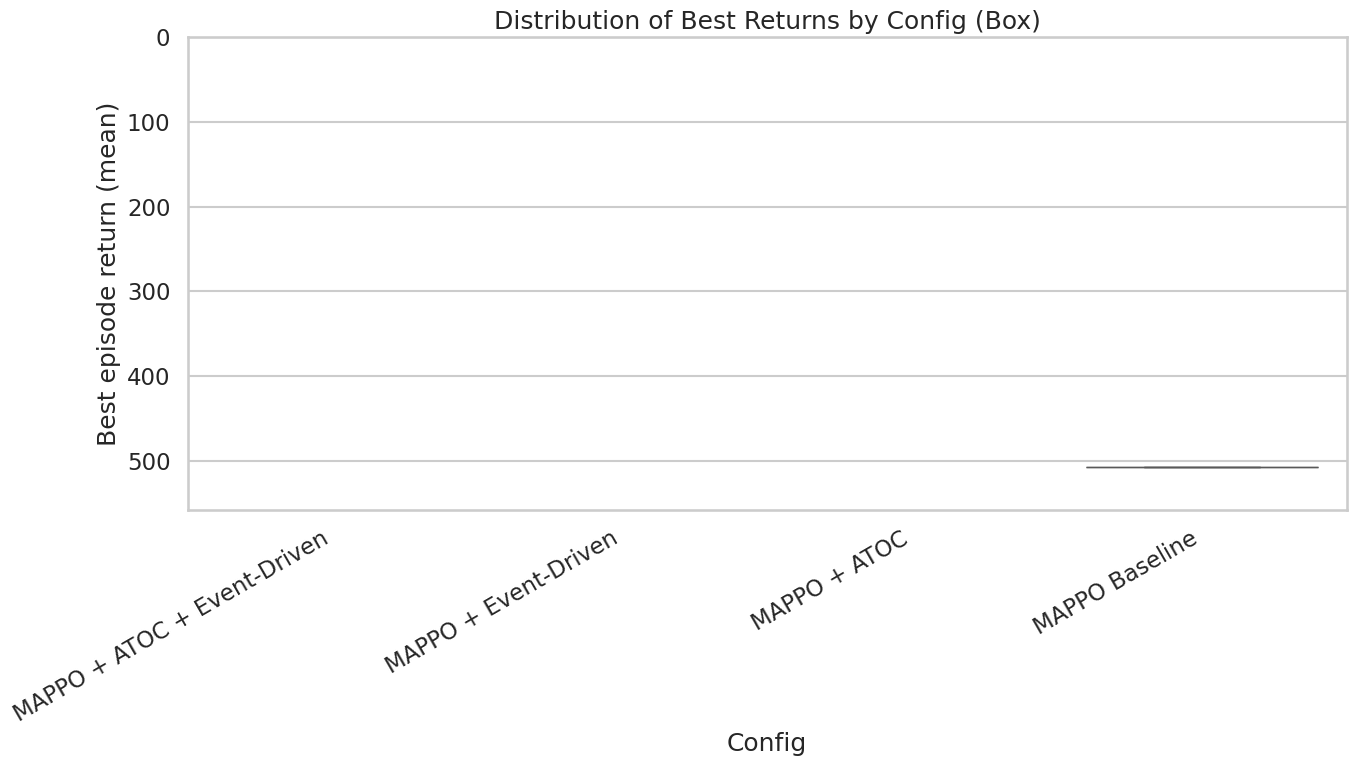

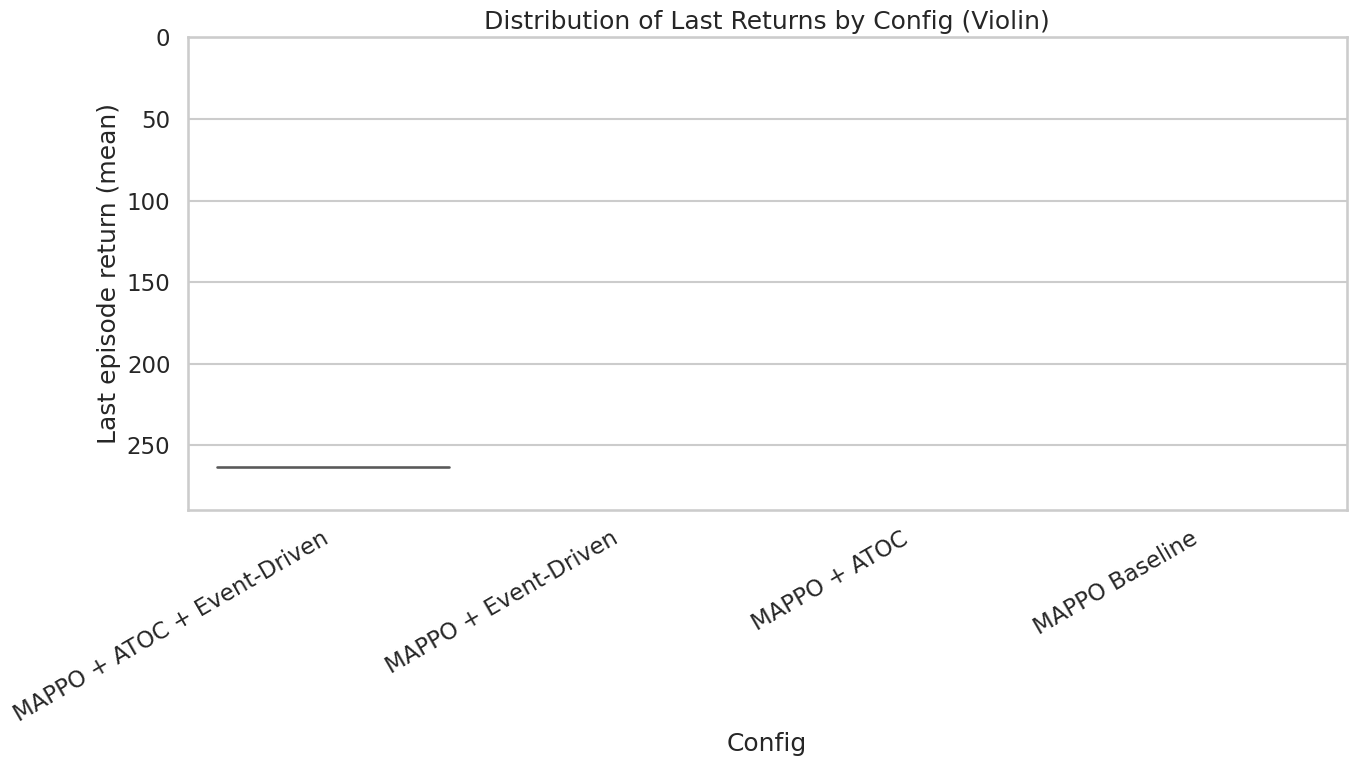

In [12]:
# Box/Violin: Returns by config
plot_data = df_flat.dropna(subset=['best_return_mean']) if 'df_flat' in globals() else pd.DataFrame()
if plot_data.empty:
    print('No best_return_mean values to plot for distributions.')
else:
    # Compute y-axis bounds for consistency
    ymin_ret = float(plot_data['best_return_mean'].min()) if 'best_return_mean' in plot_data.columns else -100
    ymax_ret = 0
    
    plt.figure(figsize=(14, 8))
    # Use config_order for x-axis ordering
    sns.boxplot(data=plot_data, x='config', y='best_return_mean', order=config_order, hue='config', palette=config_palette, dodge=False, legend=False)
    plt.ylabel('Best episode return (mean)')
    plt.xlabel('Config')
    plt.title('Distribution of Best Returns by Config (Box)')
    plt.xticks(rotation=30, ha='right')
    plt.ylim(ymin_ret * 1.1, ymax_ret)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'box_return_by_config.png', dpi=300, transparent=True, bbox_inches='tight')
    plt.show()

    if 'last_return_mean' in df_flat.columns:
        valid_last = df_flat.dropna(subset=['last_return_mean'])
        ymin_last = float(valid_last['last_return_mean'].min()) if not valid_last.empty else -100
        plt.figure(figsize=(14, 8))
        sns.violinplot(data=valid_last, x='config', y='last_return_mean', order=config_order, hue='config', palette=config_palette, cut=0, dodge=False, legend=False)
        plt.ylabel('Last episode return (mean)')
        plt.xlabel('Config')
        plt.title('Distribution of Last Returns by Config (Violin)')
        plt.xticks(rotation=30, ha='right')
        plt.ylim(ymin_last * 1.1, 0)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'violin_return_by_config.png', dpi=300, transparent=True, bbox_inches='tight')
        plt.show()
    else:
        print('Column last_return_mean not found; skipping violin plot.')


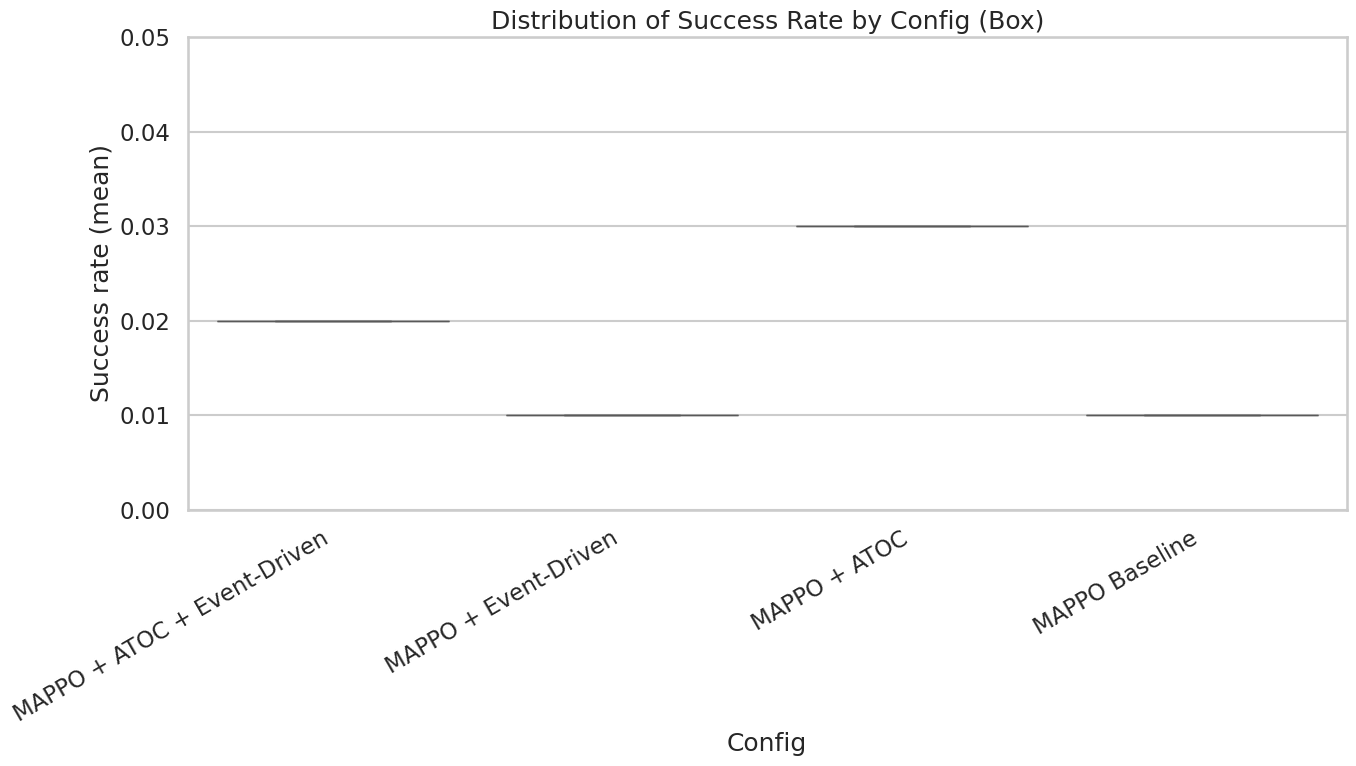

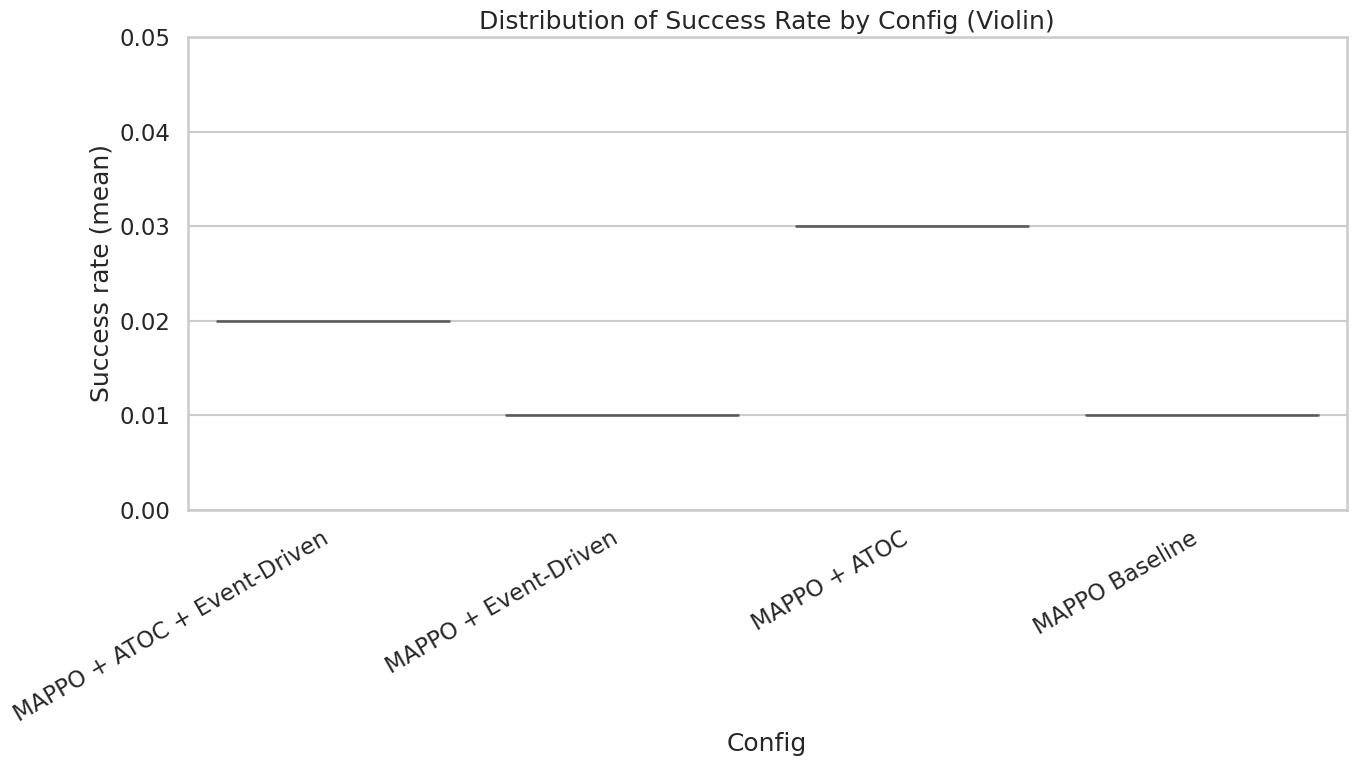

In [13]:
# Box/Violin: Success rate by config
if 'df_flat' not in globals() or df_flat.empty:
    print('No trials to visualize for success distributions.')
else:
    valid = df_flat.dropna(subset=['success_rate_mean']) if 'success_rate_mean' in df_flat.columns else pd.DataFrame()
    if valid.empty:
        print('No success_rate_mean values to plot.')
    else:
        # Compute y-axis bounds for consistency
        success_max = float(valid['success_rate_mean'].max()) if not valid.empty else 0.05
        ylim_upper = max(success_max * 1.2, 0.05)
        
        plt.figure(figsize=(14, 8))
        sns.boxplot(data=valid, x='config', y='success_rate_mean', order=config_order, hue='config', palette=config_palette, dodge=False, legend=False)
        plt.ylabel('Success rate (mean)')
        plt.xlabel('Config')
        plt.title('Distribution of Success Rate by Config (Box)')
        plt.xticks(rotation=30, ha='right')
        plt.ylim(0, ylim_upper)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'box_success_by_config.png', dpi=300, transparent=True, bbox_inches='tight')
        plt.show()

        plt.figure(figsize=(14, 8))
        sns.violinplot(data=valid, x='config', y='success_rate_mean', order=config_order, hue='config', palette=config_palette, cut=0, dodge=False, legend=False)
        plt.ylabel('Success rate (mean)')
        plt.xlabel('Config')
        plt.title('Distribution of Success Rate by Config (Violin)')
        plt.xticks(rotation=30, ha='right')
        plt.ylim(0, ylim_upper)
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'violin_success_by_config.png', dpi=300, transparent=True, bbox_inches='tight')
        plt.show()


Missing columns for success/contact scatter; skipping.


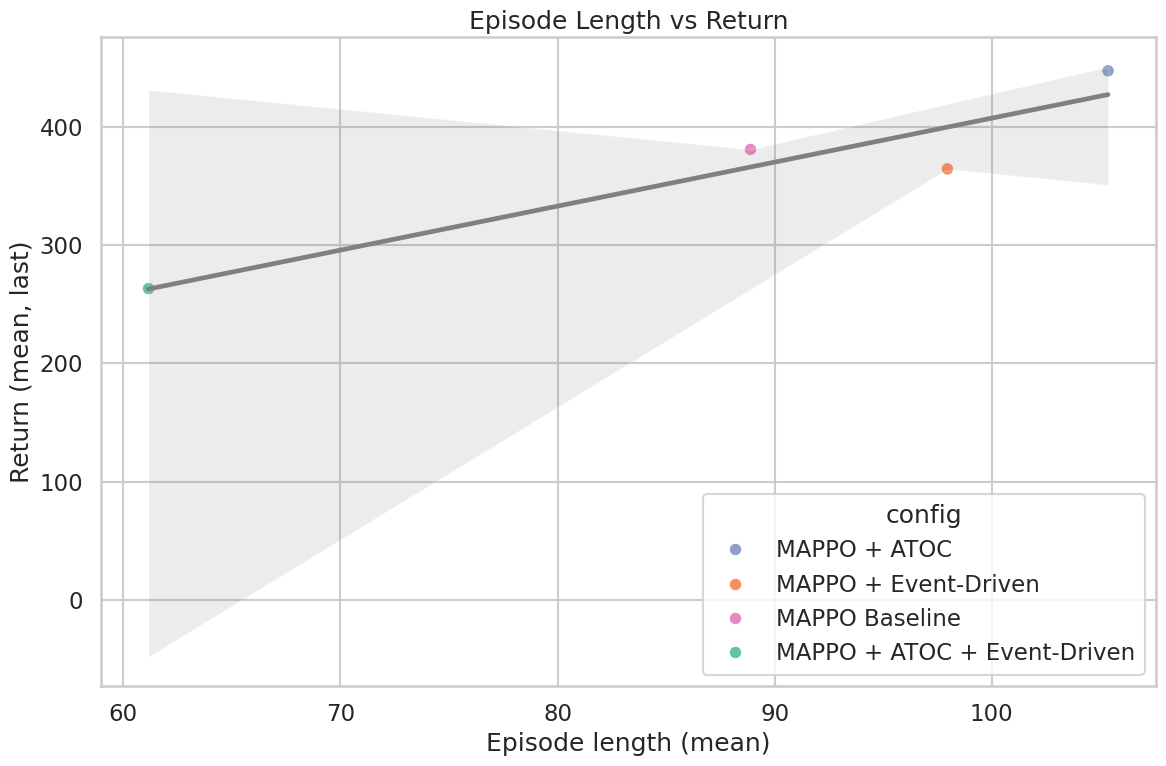

In [14]:
# Trade-off: Success vs Contact Fraction; Episode length vs Return
if 'df_flat' not in globals() or df_flat.empty:
    print('No trials to visualize for trade-offs.')
else:
    # Success vs contact fraction
    if {'success_rate_mean', 'contact_fraction', 'config'}.issubset(df_flat.columns):
        valid = df_flat.dropna(subset=['success_rate_mean', 'contact_fraction'])
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=valid, x='contact_fraction', y='success_rate_mean', hue='config', palette=config_palette)
        sns.regplot(data=valid, x='contact_fraction', y='success_rate_mean', scatter=False, color='gray')
        plt.xlabel('Contact fraction')
        plt.ylabel('Success rate (mean)')
        plt.title('Success vs Contact Fraction')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'scatter_success_vs_contact.png', dpi=300, transparent=True, bbox_inches='tight')
        plt.show()
    else:
        print('Missing columns for success/contact scatter; skipping.')

    # Episode length vs return
    if {'last_episode_len_mean', 'last_return_mean', 'config'}.issubset(df_flat.columns):
        valid = df_flat.dropna(subset=['last_episode_len_mean', 'last_return_mean'])
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=valid, x='last_episode_len_mean', y='last_return_mean', hue='config', palette=config_palette)
        sns.regplot(data=valid, x='last_episode_len_mean', y='last_return_mean', scatter=False, color='gray')
        plt.xlabel('Episode length (mean)')
        plt.ylabel('Return (mean, last)')
        plt.title('Episode Length vs Return')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'scatter_ep_len_vs_return.png', dpi=300, transparent=True, bbox_inches='tight')
        plt.show()
    else:
        print('Missing columns for ep_len/return scatter; skipping.')


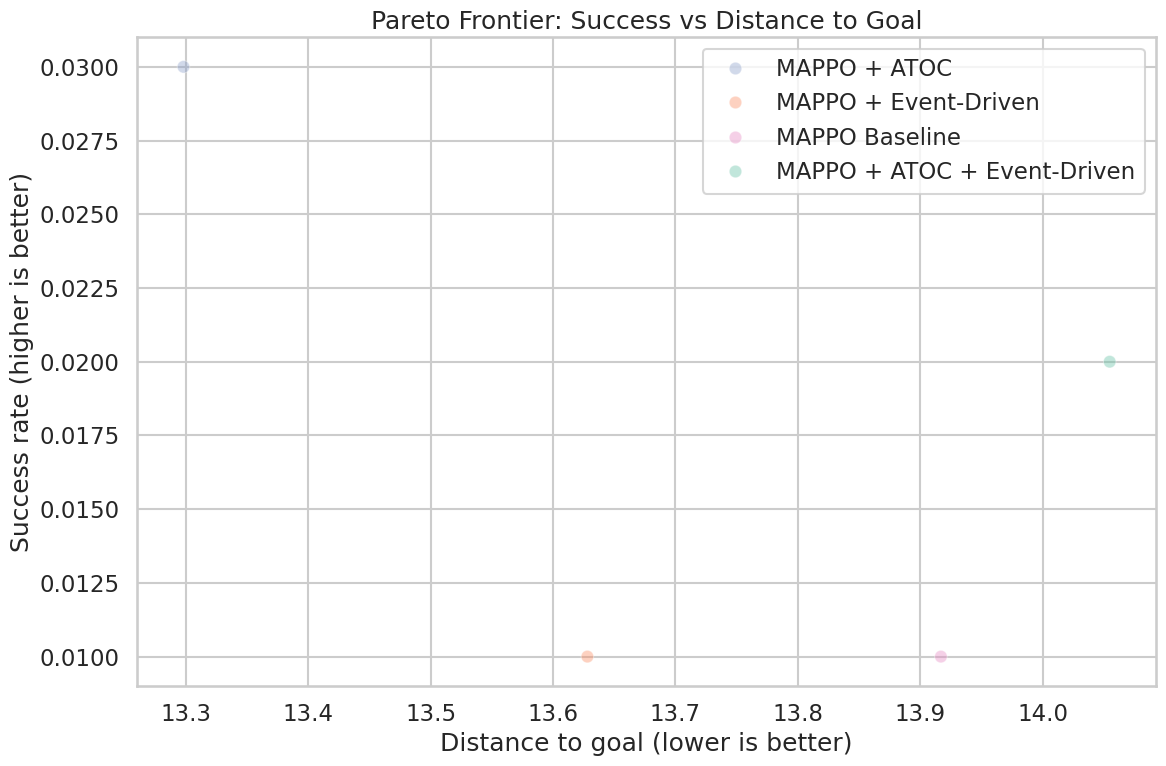

In [15]:
# Pareto frontier: success_rate_mean vs dist_to_goal

cols_ok = {'success_rate_mean', 'dist_to_goal_mean', 'config'}.issubset(df_flat.columns)
if not cols_ok:
    print('Missing columns for Pareto plot; skipping.')
else:
    valid = df_flat.dropna(subset=['success_rate_mean', 'dist_to_goal_mean']).copy()
    pareto = compute_pareto(valid, x='dist_to_goal', y='success_rate_mean', minimize_x=True, maximize_y=True)
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=valid, x='dist_to_goal_mean', y='success_rate_mean', hue='config', alpha=0.4, palette=config_palette)
    if not pareto.empty:
        plt.scatter(pareto['dist_to_goal_mean'], pareto['success_rate_mean'], s=100, facecolors='none', edgecolors='black', linewidths=1.5, label='Pareto-optimal')
    plt.xlabel('Distance to goal (lower is better)')
    plt.ylabel('Success rate (higher is better)')
    plt.title('Pareto Frontier: Success vs Distance to Goal')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

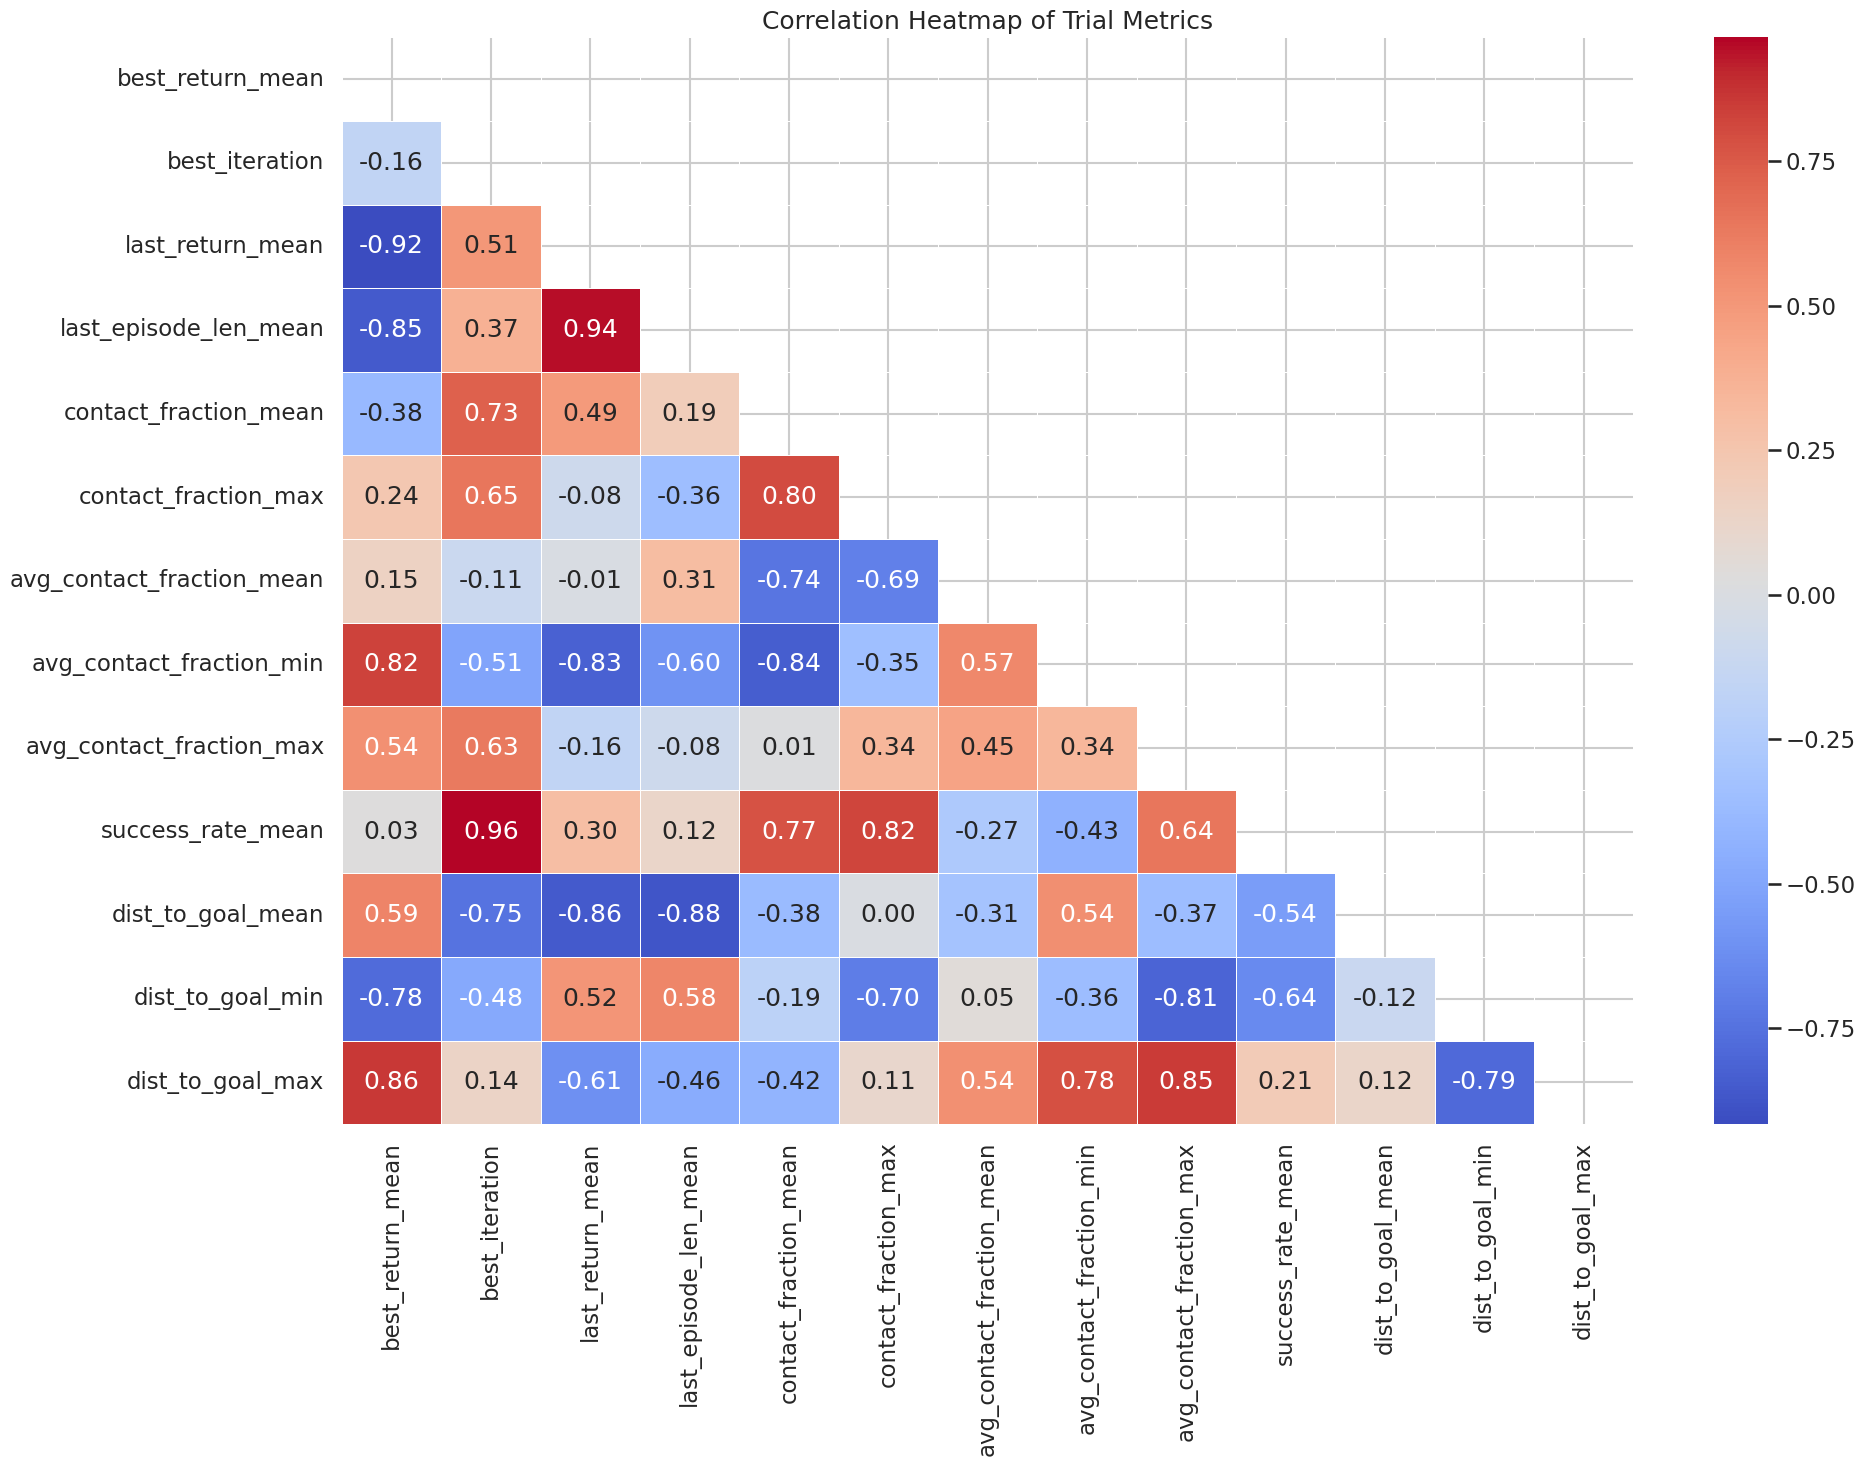

In [16]:
# Correlation heatmap across metrics

num_df = df_flat.select_dtypes(include=[np.number])
corr = num_df.corr()
# remove self-correlations or NaN values
corr = corr.dropna(axis=1, how='all').dropna(axis=0, how='all')
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(20, 15))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Trial Metrics")
plt.tight_layout()
plt.show()

best_return_mean              success_rate_mean        last_episode_len_mean          \
                                        mean       median              mean median                  mean  median   
config                                                                                                             
MAPPO + ATOC                      604.991077   604.991077              0.03   0.03                105.36  105.36   
MAPPO + ATOC + Event-Driven      2374.725305  2374.725305              0.02   0.02                 61.16   61.16   
MAPPO + Event-Driven             1205.181789  1205.181789              0.01   0.01                 97.96   97.96   
MAPPO Baseline                    506.759990   506.759990              0.01   0.01                 88.89   88.89   

                            contact_fraction_mean        dist_to_goal_mean             
                                             mean median              mean     median  
config                                                                                 
MAPPO + ATOC                                0.408  0.408         13.298124  13.298124  
MAPPO + ATOC + Event-Driven                 0.392  0.392         14.054761  14.054761  
MAPPO + Event-Driven                        0.378  0.378         13.628095  13.628095  
MAPPO Baseline                              0.396  0.396         13.916895  13.916895

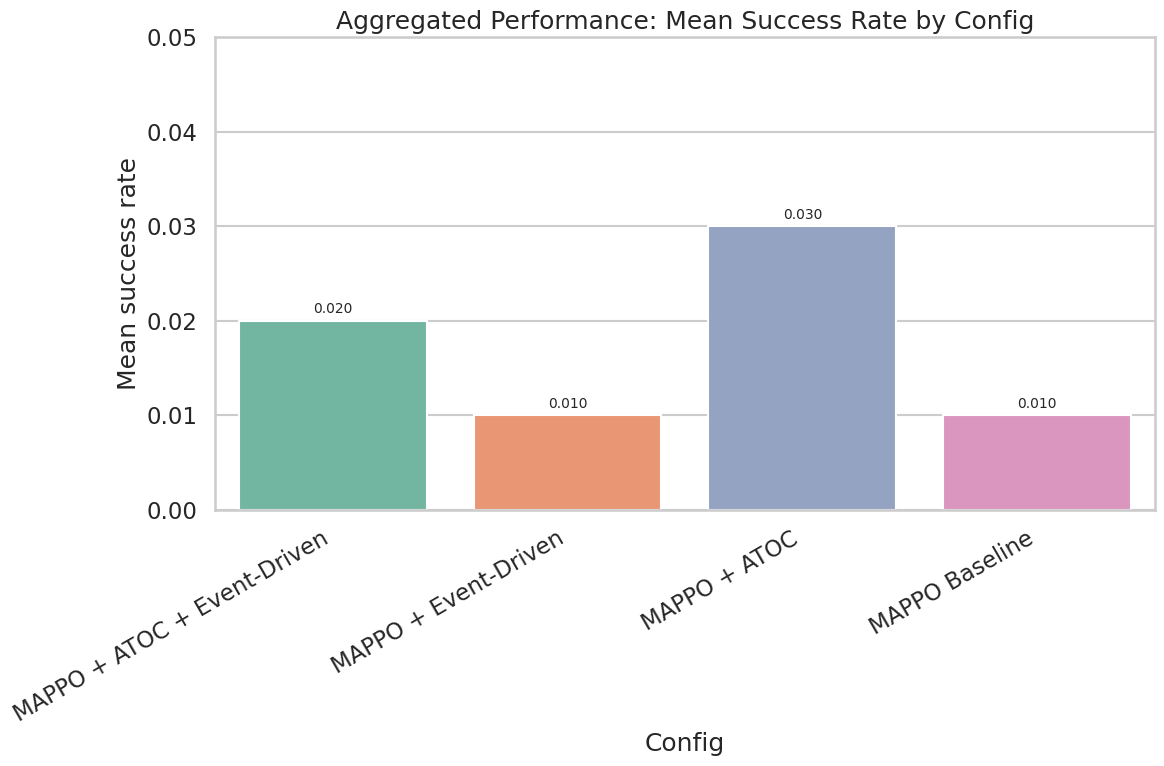

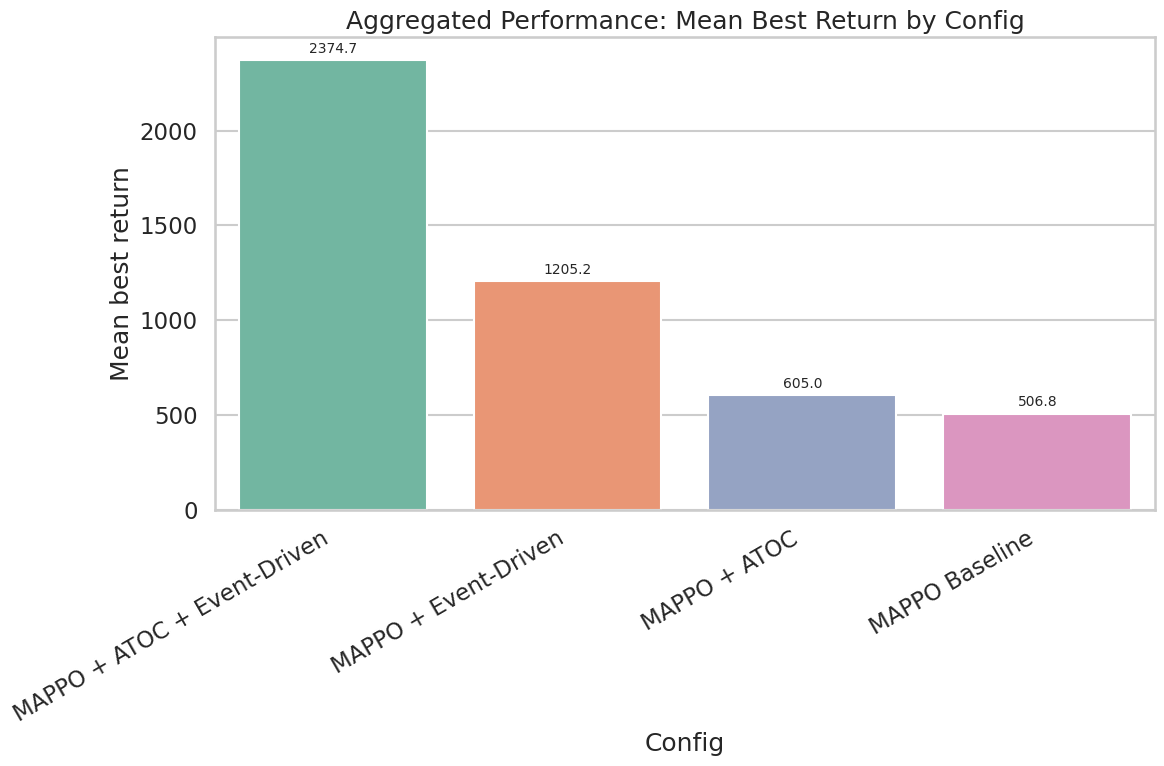

In [17]:
# Resolve metric columns that may have different suffixes
def resolve_col(preferred, fallbacks):
    for c in [preferred] + fallbacks:
        if c in df_flat.columns:
            return c
    return None


# Helper to annotate bars
def annotate_bars(ax, fmt="{:.3f}"):
    for p in ax.patches:
        height = p.get_height()
        if np.isfinite(height):
            ax.annotate(
                fmt.format(height),
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=10,
                rotation=0,
                xytext=(0, 3),
                textcoords="offset points",
            )


best_return_col = resolve_col(
    "best_return_mean",
    ["env_runners/episode_return_mean", "env_runners/episode_reward_mean"],
)
success_col = resolve_col("success_rate_mean", ["success_rate"])
ep_len_col = resolve_col("last_episode_len_mean", ["episode_len_mean"])
contact_col = resolve_col("contact_fraction", ["contact_fraction_mean"])
dist_col = resolve_col("dist_to_goal", ["dist_to_goal_mean"])

agg_spec = {}
for name, col in [
    ("best_return_mean", best_return_col),
    ("success_rate_mean", success_col),
    ("last_episode_len_mean", ep_len_col),
    ("contact_fraction", contact_col),
    ("dist_to_goal", dist_col),
]:
    if col is not None:
        agg_spec[col] = ["mean", "median"]

if not agg_spec:
    print("No aggregatable metric columns found; skipping summary.")
else:
    agg = df_flat.groupby("config").agg(agg_spec)
    display(agg)

    # Build a compact dataframe for bars (only for metrics we have), sorted by config_order
    bar_df = (
        df_flat.groupby("config")
        .agg({c: "mean" for c in [success_col, best_return_col] if c is not None})
        .reset_index()
    )
    # Apply consistent ordering
    bar_df["config"] = pd.Categorical(
        bar_df["config"], categories=config_order, ordered=True
    )
    bar_df = bar_df.sort_values("config")

    if success_col is not None and success_col in bar_df.columns:
        plt.figure(figsize=(12, 8))
        ax1 = sns.barplot(
            data=bar_df,
            x="config",
            y=success_col,
            order=config_order,
            hue="config",
            palette=config_palette,
            dodge=False,
            legend=False,
        )
        ax1.set_ylabel("Mean success rate")
        ax1.set_xlabel("Config")
        ax1.set_title("Aggregated Performance: Mean Success Rate by Config")
        plt.xticks(rotation=30, ha="right")
        # Normalize axis for readability (0 to small upper bound)
        upper = (
            float(bar_df[success_col].max()) if success_col in bar_df.columns else 0.05
        )
        plt.ylim(0, max(upper * 1.2, 0.05))
        annotate_bars(ax1, fmt="{:.3f}")
        plt.tight_layout()
        plt.savefig(
            FIG_DIR / "bar_agg_success_by_config.png",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )
        plt.show()
    else:
        print("Success metric not found; skipping success bar chart.")

    if best_return_col is not None and best_return_col in bar_df.columns:
        plt.figure(figsize=(12, 8))
        ax2 = sns.barplot(
            data=bar_df,
            x="config",
            y=best_return_col,
            order=config_order,
            hue="config",
            palette=config_palette,
            dodge=False,
            legend=False,
        )
        ax2.set_ylabel("Mean best return")
        ax2.set_xlabel("Config")
        ax2.set_title("Aggregated Performance: Mean Best Return by Config")
        plt.xticks(rotation=30, ha="right")
        # Normalize axis: returns often negative; clamp upper to 0
        annotate_bars(ax2, fmt="{:.1f}")
        plt.tight_layout()
        plt.show()
    else:
        print("Best return metric not found; skipping best return bar chart.")